Profit Margin Trend

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"C:\Users\Talib\Desktop\DA - Projects\New Project Resume\Dataset\files v2\Cleaned Data\Fact_Sales.csv")
df

YEARLY PROFIT & MARGIN

In [19]:

# ১. Order_Date কে datetime ফরম্যাটে রূপান্তর
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%y')

# ২. শুধু বছর (Year) অনুযায়ী গ্রুপ করা
yearly_profit = (
    df.groupby(df['Order_Date'].dt.year)
      .agg(
          Revenue=('Sales_BDT', 'sum'),
          Profit=('Profit_BDT', 'sum'),
          Cost=('Cost_BDT', 'sum')
      )
      .reset_index()
)

# ৩. কলামের নাম ঠিক করা
yearly_profit.rename(columns={'Order_Date': 'Year'}, inplace=True)

# ৪. Profit Margin, Profit Growth এবং Margin Change বের করা
yearly_profit['Profit_Margin_Pct'] = (yearly_profit['Profit'] / yearly_profit['Revenue']) * 100
yearly_profit['Profit_Growth_Pct'] = yearly_profit['Profit'].pct_change() * 100
yearly_profit['Margin_Change_Pp'] = yearly_profit['Profit_Margin_Pct'].diff()

print("YEARLY PROFIT ANALYSIS")
print(yearly_profit.round(2))

YEARLY PROFIT ANALYSIS
   Year      Revenue      Profit         Cost  Profit_Margin_Pct  \
0  2023  98215745.32  8915834.49  89299910.83               9.08   
1  2024  80917292.80  7926550.62  73022253.55               9.80   
2  2025  97097772.71  8884046.66  88213726.05               9.15   

   Profit_Growth_Pct  Margin_Change_Pp  
0                NaN               NaN  
1             -11.10              0.72  
2              12.08             -0.65  


MONTHLY PROFIT & MARGIN

In [20]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%y')

monthly_profit = (
    df.groupby(df['Order_Date'].dt.to_period('M'))
      .agg(
          Revenue=('Sales_BDT', 'sum'),
          Cost=('Cost_BDT', 'sum'),
          Profit=('Profit_BDT', 'sum')
      )
      .reset_index()
)

monthly_profit = monthly_profit.sort_values('Order_Date')

monthly_profit['Margin_Pct'] = (
    monthly_profit['Profit'] / monthly_profit['Revenue'] * 100
)
monthly_profit['Margin_Change_Pp'] = monthly_profit['Margin_Pct'].diff()

# ৫. কলামের নাম পরিবর্তন এবং স্ট্রিং এ রূপান্তর
monthly_profit.rename(columns={'Order_Date': 'Year_Month'}, inplace=True)
monthly_profit['Year_Month'] = monthly_profit['Year_Month'].astype(str)

print("\nMONTHLY PROFIT & MARGIN")
print(monthly_profit.round(2))


MONTHLY PROFIT & MARGIN
   Year_Month      Revenue         Cost      Profit  Margin_Pct  \
0     2023-01   8390315.47   7703700.35   686615.12        8.18   
1     2023-02   7429154.33   6892150.98   537003.35        7.23   
2     2023-03   8510256.78   7838844.19   671412.59        7.89   
3     2023-04   8480488.54   7488946.05   991542.49       11.69   
4     2023-05   7780524.26   7221818.24   558706.02        7.18   
5     2023-06   7394322.96   6582190.82   812132.14       10.98   
6     2023-07   6742566.49   6147703.67   594862.82        8.82   
7     2023-08   5506985.85   4919418.58   587567.27       10.67   
8     2023-09  11457361.44  10654234.11   803127.33        7.01   
9     2023-10   7041602.37   5970459.88  1071142.49       15.21   
10    2023-11   9783331.56   8947826.80   835504.76        8.54   
11    2023-12   9698835.27   8932617.16   766218.11        7.90   
12    2024-01   7809633.58   6860235.76   949397.82       12.16   
13    2024-02   5683661.08   5212555.

WORST MARGIN MONTHS

In [13]:
print("\nLOWEST MARGIN MONTHS")

print(
    monthly_profit
    .sort_values('Margin_Pct')
    .head(10)
    [['Year_Month', 'Revenue', 'Cost', 'Profit', 'Margin_Pct']]
    .round(2)
)



LOWEST MARGIN MONTHS
   Year_Month      Revenue         Cost      Profit  Margin_Pct
8     2023-09  11457361.44  10654234.11   803127.33        7.01
4     2023-05   7780524.26   7221818.24   558706.02        7.18
1     2023-02   7429154.33   6892150.98   537003.35        7.23
35    2025-12   8733007.21   8101480.08   631527.13        7.23
34    2025-11   7408121.70   6867614.36   540507.34        7.30
28    2025-05   7901194.82   7288180.04   613014.78        7.76
2     2023-03   8510256.78   7838844.19   671412.59        7.89
11    2023-12   9698835.27   8932617.16   766218.11        7.90
14    2024-03   5317262.23   4889912.67   427349.56        8.04
29    2025-06  17262162.98  15861113.64  1401049.34        8.12


PROFIT TREND

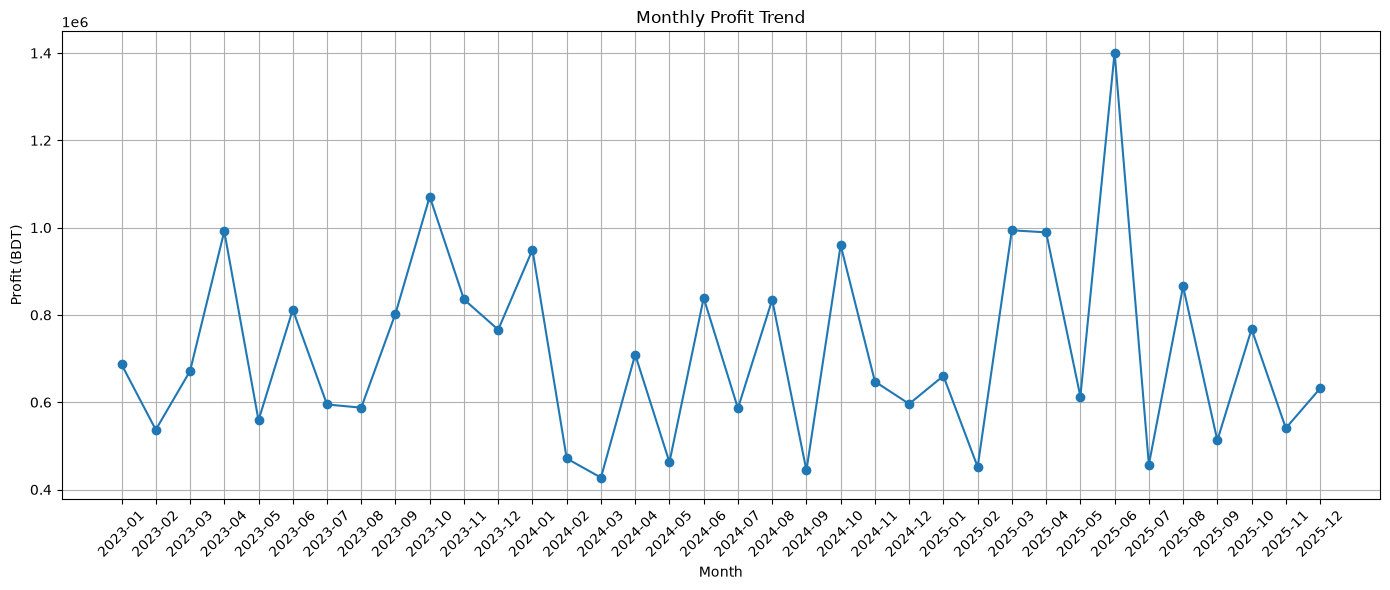

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_profit['Year_Month'],
    monthly_profit['Profit'],
    marker='o'
)

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit (BDT)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

MARGIN TREND

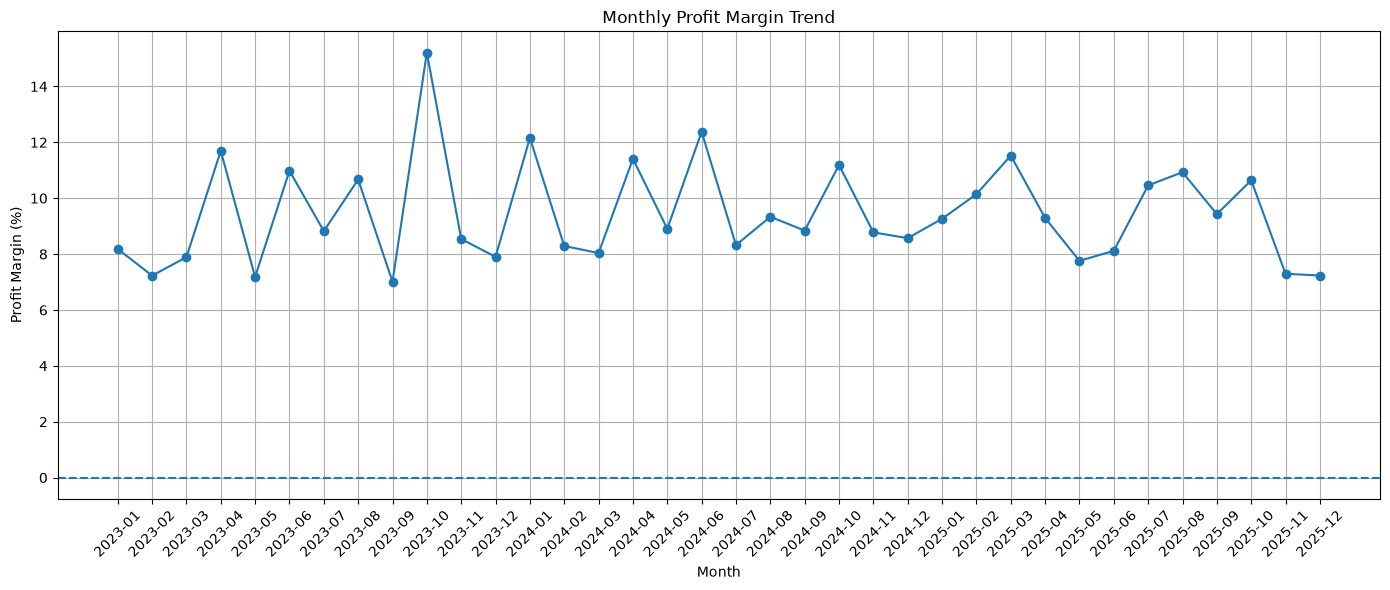

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_profit['Year_Month'],
    monthly_profit['Margin_Pct'],
    marker='o'
)

plt.axhline(0, linestyle='--')

plt.title('Monthly Profit Margin Trend')
plt.xlabel('Month')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()